In [1]:
from langchain_openai import ChatOpenAI
import os
from pydantic import SecretStr

llm = ChatOpenAI(
    model="gpt-4o-mini",
    base_url="https://openrouter.ai/api/v1",
    api_key=SecretStr(os.environ["OPENROUTER_API_KEY"]),
    temperature=0,
)   
llm

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0', 'langchain-openai': '1.6.0'}}, profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001998D9327E0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001998E32A690>, root_client=<openai.OpenAI object at 0x000001998D776600>

In [2]:
from langchain_community.tools import tool

C:\Users\GautamSukhani\AppData\Local\Temp\ipykernel_15512\3868577644.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import tool


In [3]:
from langchain_community.tools import DuckDuckGoSearchRun

@tool
def search_duckduckgo(query: str) -> str:
    """Searches DuckDuckGo for the given query to find relevant information and returns the results."""
    duckduckgo_search = DuckDuckGoSearchRun()
    return duckduckgo_search.invoke(query)

#search_duckduckgo.invoke("What is the capital of France?")

In [4]:
from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper

@tool
def search_arxiv(query: str) -> str:
    """Searches Arxiv for the given query to find relevant papers and returns the results."""
    arxiv_search = ArxivQueryRun(
        api_wrapper=ArxivAPIWrapper(top_k_results=5, get_full_documents=True)
    )
    return arxiv_search.invoke(query)

#search_arxiv.invoke("quantum computing")

In [5]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

@tool
def search_wikipedia(query: str) -> str:
    """Searches Wikipedia for the given query to find relevant information and returns the results."""
    wiki_search = WikipediaQueryRun(
        api_wrapper=WikipediaAPIWrapper(top_k_results=5, get_full_documents=True)
    )
    return wiki_search.invoke(query)

#search_wikipedia.invoke("quantum computing")

In [6]:
@tool
def personal_info(name: str):
    """
    Use this tool to get access to get personal information about someone
    Args:
        name (str): _description_
    """
    info={
        "Alice": "Alice is a software engineer with 5 years of experience in web development. She specializes in front-end technologies and has a passion for creating user-friendly interfaces.",
        "Bob": "Bob is a data scientist with a background in machine learning and statistical analysis. He has worked on various projects involving predictive modeling and data visualization.",
        "Charlie": "Charlie is a project manager with expertise in agile methodologies. He has successfully led cross-functional teams and delivered complex projects on time and within budget.",
    }
    return info.get(name, "No information available for this person.")

#personal_info.invoke("Alice")

In [7]:
tools = [search_duckduckgo, search_arxiv, search_wikipedia, personal_info]

llm_with_tools= llm.bind_tools(tools)

In [8]:
response=llm_with_tools.invoke("Who is Alice and what is the capital of France?")
response.tool_calls

[{'name': 'personal_info',
  'args': {'name': 'Alice'},
  'id': 'call_WJzXTDXJtSOk2CsHEFZH1Fzg',
  'type': 'tool_call'},
 {'name': 'search_wikipedia',
  'args': {'query': 'capital of France'},
  'id': 'call_3SjeYaQnxlLqixqczjgQquyR',
  'type': 'tool_call'}]

## LangGraph Creation

In [9]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    messages: List

In [10]:
from langchain_core.prompts import ChatPromptTemplate


def llm_node(state:graph_schema) -> graph_schema:

    messages = state["messages"]
    prompt= ChatPromptTemplate.from_messages(
          [
               ("system", "You are a helpful assistant that can use tools to answer questions."),
               ("user", "{input}")
          ])

    chain = prompt | llm_with_tools

    response = chain.invoke({"input": messages})

    state["messages"]=messages+[response]
    return state


In [29]:
#from langgraph.prebuilt import ToolNode

from langchain_core.messages import ToolMessage, HumanMessage


def tool_node(state:graph_schema) -> graph_schema:

    messages = state["messages"]

    tools_by_name = {tool.name: tool for tool in tools}

    tool_results = []

    for tool_call in messages[-1].tool_calls:
        tool=tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        tool_results.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))

    state["messages"]=messages+tool_results
    return state

In [27]:
def if_tool_call(state:graph_schema) -> str:
    messages = state["messages"]

    if isinstance(messages[-1], ToolMessage):
        return "tool_call"
    else:
        return "end"

In [28]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("llm_node", llm_node)
graph.add_node("tool_node", tool_node)

graph.add_edge(START, "llm_node")

graph.add_conditional_edges("llm_node", if_tool_call,{"tool_node":"tool_node", "end":END})

graph.add_edge("tool_node", "llm_node")

graph.add_edge("llm_node", END)

react_graph = graph.compile()

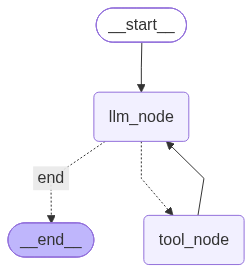

In [24]:
from IPython.display import display

display(react_graph)

In [30]:
react_graph.invoke({"messages": [HumanMessage(content="Who is Alice and what is the capital of France?")]})

{'messages': [HumanMessage(content='Who is Alice and what is the capital of France?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 192, 'total_tokens': 240, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'text_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None, 'video_tokens': 0}, 'cost': 5.76e-05, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 5.76e-05, 'upstream_inference_prompt_cost': 2.88e-05, 'upstream_inference_completions_cost': 2.88e-05}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-4o-mini', 'system_fingerprint': 'fp_05efaf2759', 'id': 'gen-1789710024-HvW5A6kEA7neiLtxg2xT', 'finish_reason': 'tool_calls', 'lo

In [31]:
for chunk in react_graph.stream({"messages": [HumanMessage(content="Who is Alice and what is the capital of France?")]},
                                 stream_mode="updates"):
    print(chunk, end="")

{'llm_node': {'messages': [HumanMessage(content='Who is Alice and what is the capital of France?', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 192, 'total_tokens': 240, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'text_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None, 'video_tokens': 0}, 'cost': 5.76e-05, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 5.76e-05, 'upstream_inference_prompt_cost': 2.88e-05, 'upstream_inference_completions_cost': 2.88e-05}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-4o-mini', 'system_fingerprint': 'fp_05efaf2759', 'id': 'gen-1789710102-1JuscyroklS6Nek7PHiF', 'finish_reason': 'tool_